<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# BSM Analysis — Sterile Neutrino (3+1): Experimental Anomalies and Constraints
---

This notebook connects the 3+1 sterile neutrino framework in tpeanuts to
**real experimental data**: reactor and Gallium anomalies ($\nu_e$ disappearance),
LSND and MiniBooNE ($\nu_\mu\to\nu_e$ appearance), and IceCube atmospheric
constraints ($\nu_\mu$ disappearance). A closing section quantifies the global
tension between these channels in the 3+1 parameter space.

Third notebook of the 3+1 sterile-neutrino series (`sterile1_test.ipynb` verifies
the framework is correct; `sterile2_kinematics.ipynb` establishes the definitions,
experiment characteristics, theoretical predictions, and the validity range of the
2-flavour approximation used throughout). This notebook assumes that background and
focuses on the forward-prediction-vs-data comparison itself.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background** — anomaly summary, global-tension framing |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Configuration** — paths, experiment table, helpers |
| [3](#3.-νe-Disappearance-–-Reactor-Anomaly) | **Reactor Anomaly** — rate deficit at $L<100$ m |
| [4](#4.-νe-Disappearance-–-Gallium-Anomaly) | **Gallium Anomaly** — SAGE / GALLEX / BEST at $L\sim1$ m |
| [5](#5.-νμ→νe-Appearance-–-LSND-and-MiniBooNE) | **LSND / MiniBooNE** — appearance excess at short baseline |
| [6](#6.-νμ-Disappearance-–-IceCube-Atmospheric) | **IceCube** — $\nu_\mu$ disappearance at multi-TeV |
| [7](#7.-Global-Tension:-Appearance-vs-Disappearance) | **Global Tension** — parameter-space compatibility scan |
| [∑](#Summary) | **Summary** |

## 0. Theory Background

### 0.1 The Short-Baseline Anomalies (summary)

Three classes of anomaly hint at $\nu_e$ production or disappearance beyond the SM.
Full definitions, experiment characteristics, and the theoretical prediction formulae
(with their validity ranges) are given in `sterile2_kinematics.ipynb`, Section 0; the
short recap below only fixes notation for this notebook.

**Reactor Anomaly** *(Mention et al. 2011)*: Recalculated reactor antineutrino fluxes
predict a $\sim6\%$ deficit in $\approx19$ short-baseline ($L<100$ m) experiments.
This is consistent with $\bar\nu_e\to\bar\nu_s$ oscillations with
$\Delta m^2_{41}\sim1\ \text{eV}^2$.

**Gallium Anomaly** *(Giunti & Laveder 2010; Barinov et al. 2022)*: Source-calibration
experiments (SAGE, GALLEX, BEST) with $^{51}$Cr and $^{37}$Ar sources at $L\lesssim2$ m
observe a ratio $R=N_{\rm obs}/N_{\rm pred}\approx0.78$–0.86. BEST (2022) confirms
the deficit at $\sim5\sigma$.

**LSND** *(Aguilar et al. 2001)* and **MiniBooNE** *(Aguilar-Arevalo et al. 2018)*:
$\bar\nu_\mu\to\bar\nu_e$/$\nu_\mu\to\nu_e$ appearance excesses at short baseline,
characterized by an effective amplitude
$\sin^2(2\theta_{e\mu}^{\rm eff})=\sin^2(2\theta_{14})\sin^2\theta_{24}\sim0.003$–0.030.

**IceCube 2020** *(arXiv:2005.12943)*: Through-going atmospheric $\nu_\mu$ at TeV
energies constrain $\nu_\mu$ disappearance to the sterile channel:
$\sin^2(2\theta_{24}) < 0.10$ at $\Delta m^2_{41}=0.3\ \text{eV}^2$.

---

### 0.2 Global Tension

The appearance amplitude $A_{e\mu}^{\rm eff}=\sin^2(2\theta_{14})\sin^2\theta_{24}$
required by LSND/MiniBooNE is $\sim0.003$–$0.030$. However, reactor data constrains
$\sin^2(2\theta_{14})\lesssim0.10$ and IceCube constrains $\sin^2(2\theta_{24})\lesssim0.10$,
giving $A_{e\mu}^{\rm eff}\lesssim0.003$ — barely compatible with the minimum required by
LSND. This **appearance vs disappearance tension** exceeds $3\sigma$ globally and
constitutes the central problem of the 3+1 scenario. Section 7 below quantifies this
tension directly with tpeanuts forward predictions.

---

**References**
- Mention, G. et al. (2011). Phys. Rev. D **83**, 073006. (Reactor anomaly)
- Barinov, V. V. et al. (BEST) (2022). Phys. Rev. Lett. **128**, 232501.
- Aguilar, A. et al. (LSND) (2001). Phys. Rev. D **64**, 112007.
- Aguilar-Arevalo, A. A. et al. (MiniBooNE) (2018). Phys. Rev. Lett. **121**, 221801.
- IceCube Collaboration (2020). Phys. Rev. Lett. **125**, 141801. arXiv:2005.12943.
- Giunti, C., Marrone, A. & Palazzo, A. (2017). arXiv:1612.01087.

## 1. Libraries

In [1]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
%matplotlib inline

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.BSM.bsm_sterile import PMNSSterileParams, PMNS_sterile
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show
from tpeanuts.util.context import RuntimeContext

print(f"torch {torch.__version__}")

torch 2.5.1+cu121


## 2. Paths and Configuration

### 2.1 Paths

In [2]:
config     = load_notebook_config()
context    = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("analysis", "bsm")

print(f"Package dir : {config.package_dir}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Device      : {context.device}   dtype: {context.dtype}")

Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\analysis\bsm
Device      : cuda:0   dtype: torch.float64


### 2.2 Configuration

Experiments are organized by oscillation channel. tpeanuts computes **forward predictions**
(oscillation probabilities) which are then compared with published measurements.

| Experiment | Channel | $L$ [m] | $E$ [MeV] | $\Delta m^2_{41}$ sensitivity | Reference |
|------------|---------|---------|----------|-------------------------------|-----------|
| Reactor (ILL, Bugey) | $\bar\nu_e$ disappear. | 15–95 | 2–8 | $\sim1\ \text{eV}^2$ | Mention 2011 |
| BEST (Gallium) | $\nu_e$ disappear. | 0.5–2 | 0.75–0.81 | $\sim1\ \text{eV}^2$ | Barinov 2022 |
| LSND | $\bar\nu_\mu\to\bar\nu_e$ appear. | 30 | 20–52 | $\sim1\ \text{eV}^2$ | Aguilar 2001 |
| MiniBooNE | $\nu_\mu\to\nu_e$ appear. | 541 | 200–3000 | $\sim1\ \text{eV}^2$ | Aguilar-Arevalo 2018 |
| IceCube | $\nu_\mu$ disappear. | $10^4$–$10^7$ | $5\times10^5$–$10^7$ | 0.1–10 eV$^2$ | IceCube 2020 |

In [3]:
# Load presets
osc_null   = PropagationConfig.oscillation_parameters_from_preset("sterile_3p1_null_mixing",     context=context)
osc_giunti = PropagationConfig.oscillation_parameters_from_preset("sterile_3p1_bestfit_giunti2017", context=context)
osc_ic     = PropagationConfig.oscillation_parameters_from_preset("sterile_3p1_benchmark_icecube",  context=context)

# Print key parameters
presets = [
    ("Null 3+1",    osc_null),
    ("Giunti 2017", osc_giunti),
    ("IceCube",     osc_ic),
]
for label, osc in presets:
    sp  = osc.pmns.sterile_params
    th14 = math.degrees(float(sp.theta14))
    th24 = math.degrees(float(sp.theta24))
    Dm41 = float(osc.mass_spectrum.DeltamSq41)
    A_eff = math.sin(2 * float(sp.theta14))**2 * math.sin(float(sp.theta24))**2
    print(f"{label:15s}: theta14={th14:.2f} deg  theta24={th24:.2f} deg  "
          f"Dm41={Dm41:.2f} eV^2  sin^2(2theta_emu)_eff={A_eff:.5f}")

Null 3+1       : theta14=0.00 deg  theta24=0.00 deg  Dm41=1.00 eV^2  sin^2(2theta_emu)_eff=0.00000
Giunti 2017    : theta14=8.50 deg  theta24=7.50 deg  Dm41=1.70 eV^2  sin^2(2theta_emu)_eff=0.00146
IceCube        : theta14=0.00 deg  theta24=9.22 deg  Dm41=0.30 eV^2  sin^2(2theta_emu)_eff=0.00000


### 2.3 Helper Functions

In [ ]:
from tpeanuts.core.common.potential import kinetic_potential


@torch.no_grad()
def vac_prob_4nu(oscillation, E_MeV, L_km):
    """4x4 vacuum oscillation probability matrix P[beta, alpha] (beta=row, alpha=col).

    Reuses the exact production phase convention (``kinetic_potential``) by
    passing ``L_km*1000`` (metres) directly as ``evolution_scale_m``, matching
    ``medium.vacuum.evolutor.vacuum_evolutor``. An earlier version of this
    helper used a hand-rolled ``PHASE_FACTOR = 1.267e3`` constant applied
    directly to each mass eigenstate's absolute phase; that constant is only
    correct for the *difference* of two eigenstate phases (the standard
    oscillation-probability convention), so applying it to each eigenstate's
    absolute phase was off by a factor of 2 (see the same fix and its full
    explanation in ``sterile1_test.ipynb``, Section 2.3).
    """
    pmns = oscillation.pmns
    U    = pmns.pmns_matrix(antinu=oscillation.antinu)
    mass_sq = oscillation.mass_spectrum.difference_vector(context=context)
    E = torch.as_tensor(E_MeV, dtype=context.dtype, device=context.device)
    L = torch.as_tensor(L_km,  dtype=context.dtype, device=context.device)
    phases = kinetic_potential(mass_sq, E, evolution_scale_m=L * 1.0e3, context=context)
    S = (U * torch.exp(-1j * phases.to(U.dtype))[..., None, :]) @ U.conj().transpose(-1, -2)
    return S.abs().pow(2)                  # (4, 4)


def pee_scan(oscillation, L_km, E_arr):
    """P(nue->nue) for antineutrinos over an energy array at fixed L."""
    out = []
    L_t = torch.as_tensor(L_km, dtype=context.dtype, device=context.device)
    for E in E_arr:
        E_t = torch.tensor(float(E), dtype=context.dtype, device=context.device)
        P4  = vac_prob_4nu(oscillation, E_t, L_t)
        out.append(float(P4[0, 0]))       # P(nue -> nue)
    return np.array(out)
def pee_scan_over_L(oscillation, L_arr_km, E_MeV):
    """P(nue->nue) for antineutrinos over a baseline array at fixed E."""
    out = []
    E_t = torch.tensor(float(E_MeV), dtype=context.dtype, device=context.device)
    for L in L_arr_km:
        L_t = torch.tensor(float(L), dtype=context.dtype, device=context.device)
        P4  = vac_prob_4nu(oscillation, E_t, L_t)
        out.append(float(P4[0, 0]))       # P(nue -> nue)
    return np.array(out)




def pmumu_scan(oscillation, L_km, E_arr_MeV):
    """P(numu->numu) over an energy array at fixed L."""
    out = []
    L_t = torch.as_tensor(L_km, dtype=context.dtype, device=context.device)
    for E in E_arr_MeV:
        E_t = torch.tensor(float(E), dtype=context.dtype, device=context.device)
        P4  = vac_prob_4nu(oscillation, E_t, L_t)
        out.append(float(P4[1, 1]))       # P(numu -> numu)
    return np.array(out)


def pmue_scan(oscillation, L_km, E_arr_MeV):
    """P(numu->nue) appearance over an energy array at fixed L."""
    out = []
    L_t = torch.as_tensor(L_km, dtype=context.dtype, device=context.device)
    for E in E_arr_MeV:
        E_t = torch.tensor(float(E), dtype=context.dtype, device=context.device)
        P4  = vac_prob_4nu(oscillation, E_t, L_t)
        out.append(float(P4[0, 1]))       # P(numu -> nue)
    return np.array(out)


def rate_deficit(oscillation, L_km, E_arr, spectrum_weight=None):
    """Average survival probability <P(nue->nue)>_E, optionally spectrum-weighted."""
    P_arr = pee_scan(oscillation, L_km, E_arr)
    if spectrum_weight is None:
        return float(P_arr.mean())
    w = spectrum_weight / spectrum_weight.sum()
    return float((P_arr * w).sum())

## 3. $\bar\nu_e$ Disappearance — Reactor Anomaly

Reactor experiments at $L<100$ m observe an average rate deficit of $\sim6\%$ with
respect to recalculated SM flux predictions *(Mention et al. 2011)*. The 3+1 model
predicts rapid $\bar\nu_e\to\bar\nu_s$ oscillations that average to a constant
deficit $\langle P\rangle_E \approx 1 - \frac{1}{2}\sin^2(2\theta_{14})$
when $L\gg L_{\rm osc}$.

**Experiment baselines used:**
| Experiment | $L$ [m] | $\langle E\rangle$ [MeV] |
|------------|---------|--------------------------|
| ILL | 15 | 3 |
| Bugey-3 (near) | 15 | 4 |
| Bugey-3 (far1) | 40 | 4 |
| Bugey-3 (far2) | 95 | 4 |

**Expected results:**
- **SM (null)**: $\langle P\rangle=1.0$ — no deficit.
- **Giunti 2017** ($\theta_{14}=8.5°$, $\Delta m^2_{41}=1.7\ \text{eV}^2$): at these baselines
  ($L\gg L_{\rm osc}$, oscillations already averaged over the energy window), the deficit
  should sit close to its asymptotic value $\approx\frac{1}{2}\sin^2(2\theta_{14})\approx3.5\%$.
- **Observed**: $\sim6\%$ deficit (requires larger $\theta_{14}$ than Giunti 2017 alone).

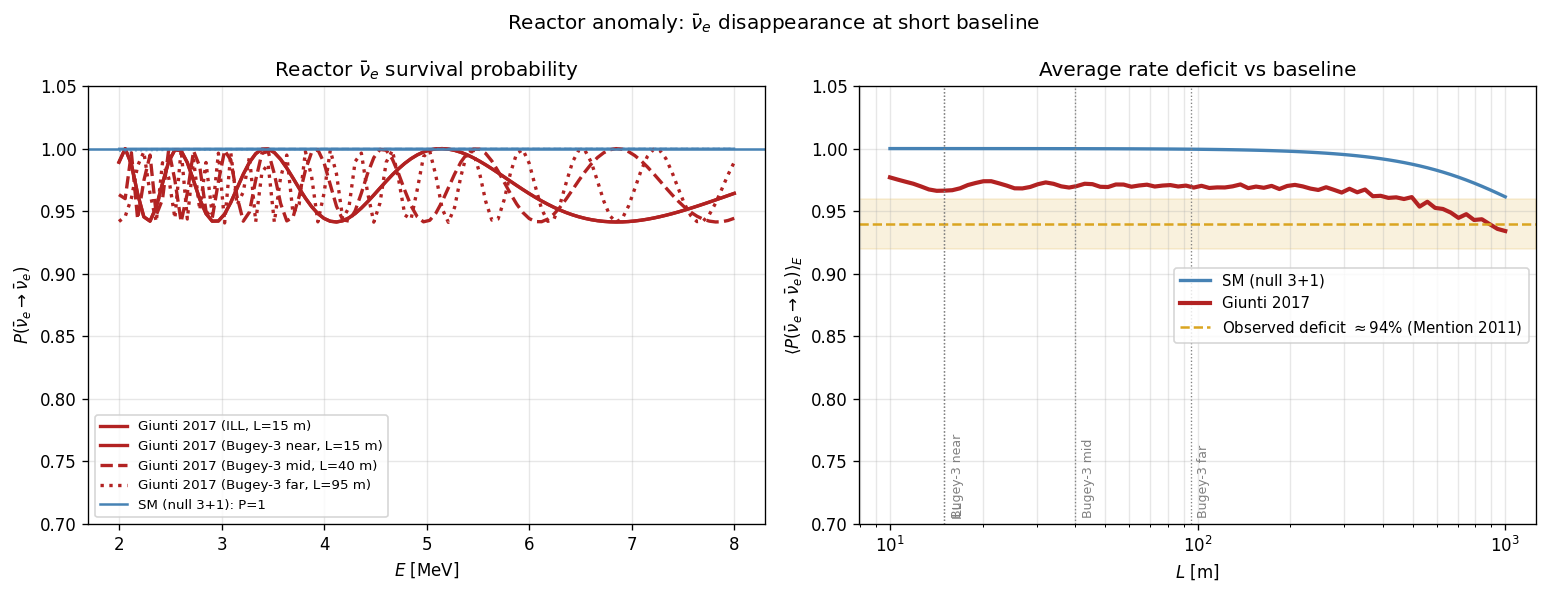

v:\output\analysis\bsm\st2_fig3_reactor.png
Average rate deficit at reactor baselines:
  ILL                (L=15 m): Giunti P_avg = 0.9664  deficit = 3.36%
  Bugey-3 near       (L=15 m): Giunti P_avg = 0.9664  deficit = 3.36%
  Bugey-3 mid        (L=40 m): Giunti P_avg = 0.9695  deficit = 3.05%
  Bugey-3 far        (L=95 m): Giunti P_avg = 0.9694  deficit = 3.06%
  Observed: deficit ~6% (R~0.94, Mention et al. 2011)


In [5]:
reactor_baselines = {"ILL": 0.015, "Bugey-3 near": 0.015, "Bugey-3 mid": 0.040, "Bugey-3 far": 0.095}
E_reactor = np.linspace(2.0, 8.0, 100)   # MeV

# Antineutrino mode
import dataclasses
osc_null_anu   = dataclasses.replace(osc_null,   antinu=True)
osc_giunti_anu = dataclasses.replace(osc_giunti, antinu=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: P(nue->nue) vs E at each baseline
ax = axes[0]
colors = ["steelblue", "firebrick", "firebrick", "firebrick"]
styles = ["-", "-", "--", ":"]
for (name, L_km), color, ls in zip(reactor_baselines.items(), colors, styles):
    P_null   = pee_scan(osc_null_anu,   L_km, E_reactor)
    P_giunti = pee_scan(osc_giunti_anu, L_km, E_reactor)
    ax.plot(E_reactor, P_null,   color="steelblue", lw=1.2, ls=ls, alpha=0.6)
    ax.plot(E_reactor, P_giunti, color="firebrick",  lw=2.0, ls=ls,
            label=rf"Giunti 2017 ({name}, L={L_km*1e3:.0f} m)")

ax.axhline(1.0, color="steelblue", lw=1.5, label="SM (null 3+1): P=1")
ax.set_xlabel(r"$E$ [MeV]")
ax.set_ylabel(r"$P(\bar\nu_e\to\bar\nu_e)$")
ax.set_title(r"Reactor $\bar\nu_e$ survival probability")
ax.set_ylim(0.7, 1.05)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: Average rate deficit vs L
ax = axes[1]
L_vals = np.logspace(-2, 0, 80)   # km: 10 m to 1000 m
R_null   = [rate_deficit(osc_null_anu,   L, E_reactor) for L in L_vals]
R_giunti = [rate_deficit(osc_giunti_anu, L, E_reactor) for L in L_vals]

ax.semilogx(L_vals * 1e3, R_null,   color="steelblue", lw=2.0, label="SM (null 3+1)")
ax.semilogx(L_vals * 1e3, R_giunti, color="firebrick",  lw=2.5, label="Giunti 2017")

# Measured deficit band
ax.axhspan(0.92, 0.96, alpha=0.15, color="goldenrod")
ax.axhline(0.94, color="goldenrod", lw=1.5, ls="--",
           label=r"Observed deficit $\approx 94\%$ (Mention 2011)")
for name, L_km in reactor_baselines.items():
    ax.axvline(L_km * 1e3, color="gray", lw=0.8, ls=":")
    ax.text(L_km * 1e3 * 1.05, 0.705, name, fontsize=7.5, color="gray", rotation=90, va="bottom")

ax.set_xlabel(r"$L$ [m]")
ax.set_ylabel(r"$\langle P(\bar\nu_e\to\bar\nu_e)\rangle_E$")
ax.set_title("Average rate deficit vs baseline")
ax.set_ylim(0.70, 1.05)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

fig.suptitle(r"Reactor anomaly: $\bar\nu_e$ disappearance at short baseline", fontsize=12)
fig.tight_layout()
save_and_show("st2_fig3_reactor.png", fig, output_dir=OUTPUT_DIR,
              show_plots=config.show_plots)

print("Average rate deficit at reactor baselines:")
for name, L_km in reactor_baselines.items():
    R_g = rate_deficit(osc_giunti_anu, L_km, E_reactor)
    print(f"  {name:18s} (L={L_km*1e3:.0f} m): Giunti P_avg = {R_g:.4f}  deficit = {(1-R_g)*100:.2f}%")
print(f"  Observed: deficit ~6% (R~0.94, Mention et al. 2011)")

## 4. $\nu_e$ Disappearance — Gallium Anomaly

The BEST experiment *(Barinov et al. 2022)* placed a $^{51}$Cr source
($E_\nu=0.747$ MeV) at the centre of the SAGE detector. Two measurement volumes
at different mean distances probe the $\nu_e$ survival probability:

| Volume | Mean $L$ [m] | Expected $R_{\rm BEST}$ | Measured $R_{\rm BEST}$ |
|--------|------------|------------------------|------------------------|
| Inner | $\approx0.6$ | $1.0$ (SM) | $0.79\pm0.05$ |
| Outer | $\approx1.6$ | $1.0$ (SM) | $0.77\pm0.05$ |

The average deficit $R\approx0.78$ corresponds to $\sin^2(2\theta_{14})\approx0.29$
if interpreted as $\nu_e\to\nu_s$ oscillations *(for $\Delta m^2_{41}\gg1\ \text{eV}^2$,
where the oscillation averages over the source)*.

**Expected results:**
- The fully-averaged asymptotic formula gives $R\approx1-\frac{1}{2}\sin^2(2\theta_{14})\approx0.965$
  for Giunti 2017 ($\theta_{14}=8.5°$), but BEST's baselines ($L\lesssim2$ m) are short
  enough — comparable to, not much larger than, the $\Delta m^2_{41}=1.7\ \text{eV}^2$
  oscillation length at $E=0.747$ MeV — that the oscillation is *not* fully averaged
  there; the numerically evaluated $R$ at the actual BEST distances differs somewhat
  from this asymptotic ceiling (see the printed values below).
- Either way, Giunti 2017 is insufficient to explain the Gallium anomaly alone;
  a larger $\theta_{14}\approx20$–$21°$ would be needed to reach $R\approx0.78$.

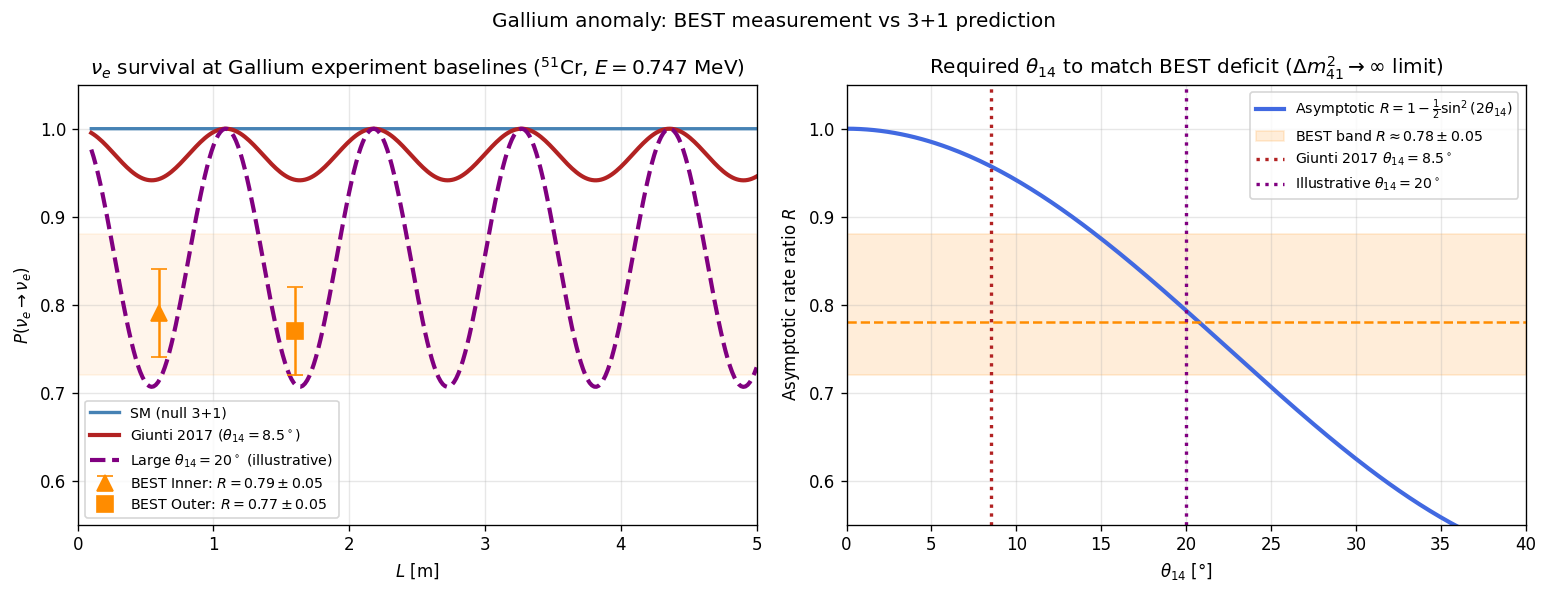

v:\output\analysis\bsm\st2_fig4_gallium.png
Rate prediction at BEST volumes for Giunti 2017:
  Inner (BEST): R_Giunti=0.9428   R_BEST_obs~0.78  -> needs larger theta14
  Outer (BEST): R_Giunti=0.9419   R_BEST_obs~0.78  -> needs larger theta14
Theta14 needed for R=0.78 (asymptotic): 20.8 deg


In [6]:
# Source energies (in MeV)
E_Cr51 = 0.747    # Cr-51 main line
E_Ar37 = 0.811    # Ar-37 (SAGE calibration)

# Mean distances
L_BEST = {"Inner (BEST)": 0.6e-3, "Outer (BEST)": 1.6e-3}  # km

# Scan L from 0 to 5 m
L_arr = np.linspace(0.1e-3, 5.0e-3, 300)   # km

# P(nue->nue) at Cr-51 energy
P_null_cr   = pee_scan_over_L(osc_null,   L_arr, E_Cr51)
P_giunti_cr = pee_scan_over_L(osc_giunti, L_arr, E_Cr51)

# Build a large-theta14 case to show the Gallium-preferred region
from tpeanuts.core.common.pmns import PMNSParams
import dataclasses

th14_best = math.radians(20.0)   # larger theta14 needed for BEST
sp_best = PMNSSterileParams(
    theta14=th14_best, theta24=0.0, theta34=0.0,
    delta14=0.0,       delta24=0.0, delta34=0.0,
    context=context,
)
pmns_best = PMNS_sterile(osc_giunti.pmns.params, sp_best)
osc_best  = dataclasses.replace(osc_giunti, pmns=pmns_best)
P_best_cr = pee_scan_over_L(osc_best, L_arr, E_Cr51)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
L_m = L_arr * 1e3
ax.plot(L_m, P_null_cr,   color="steelblue", lw=2.0, label="SM (null 3+1)")
ax.plot(L_m, P_giunti_cr, color="firebrick",  lw=2.5, label=r"Giunti 2017 ($\theta_{{14}}=8.5^\circ$)")
ax.plot(L_m, P_best_cr,   color="purple",     lw=2.5, ls="--",
        label=r"Large $\theta_{{14}}=20^\circ$ (illustrative)")

# BEST measurements
ax.errorbar(0.6, 0.79, yerr=0.05, fmt="^", color="darkorange", ms=10, capsize=5,
            zorder=5, label=r"BEST Inner: $R=0.79\pm0.05$")
ax.errorbar(1.6, 0.77, yerr=0.05, fmt="s", color="darkorange", ms=10, capsize=5,
            zorder=5, label=r"BEST Outer: $R=0.77\pm0.05$")

ax.axhspan(0.72, 0.88, alpha=0.08, color="darkorange")
ax.set_xlabel(r"$L$ [m]")
ax.set_ylabel(r"$P(\nu_e\to\nu_e)$")
ax.set_title(r"$\nu_e$ survival at Gallium experiment baselines ($^{51}$Cr, $E=0.747$ MeV)")
ax.set_ylim(0.55, 1.05)
ax.set_xlim(0, 5)
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)

# Right: average R vs theta14 (asymptotic deficit ~ 1 - sin^2(2th14)/2)
th14_vals = np.linspace(0, 40, 200)
R_asympt  = 1 - 0.5 * np.sin(np.radians(2 * th14_vals))**2
ax = axes[1]
ax.plot(th14_vals, R_asympt, color="royalblue", lw=2.5,
        label=r"Asymptotic $R = 1 - \frac{1}{2}\sin^2(2\theta_{{14}})$")
ax.axhspan(0.72, 0.88, alpha=0.15, color="darkorange",
           label=r"BEST band $R\approx0.78\pm0.05$")
ax.axhline(0.78, color="darkorange", lw=1.5, ls="--")
ax.axvline(math.degrees(float(osc_giunti.pmns.sterile_params.theta14)), color="firebrick", lw=2.0,
           ls=":", label=rf"Giunti 2017 $\theta_{{14}}={8.5:.1f}^\circ$")
ax.axvline(20.0, color="purple", lw=2.0, ls=":", label=r"Illustrative $\theta_{{14}}=20^\circ$")
ax.set_xlabel(r"$\theta_{{14}}$ [°]")
ax.set_ylabel(r"Asymptotic rate ratio $R$")
ax.set_title(r"Required $\theta_{{14}}$ to match BEST deficit ($\Delta m^2_{{41}}\to\infty$ limit)")
ax.set_xlim(0, 40)
ax.set_ylim(0.55, 1.05)
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)

fig.suptitle("Gallium anomaly: BEST measurement vs 3+1 prediction", fontsize=12)
fig.tight_layout()
save_and_show("st2_fig4_gallium.png", fig, output_dir=OUTPUT_DIR,
              show_plots=config.show_plots)

print("Rate prediction at BEST volumes for Giunti 2017:")
for name, L_km in L_BEST.items():
    R = rate_deficit(osc_giunti, L_km, [E_Cr51])
    print(f"  {name}: R_Giunti={R:.4f}   R_BEST_obs~0.78  -> needs larger theta14")
sin2_needed = 2 * (1 - 0.78)
th14_needed = 0.5 * math.degrees(math.asin(math.sqrt(sin2_needed)))
print(f"Theta14 needed for R=0.78 (asymptotic): {th14_needed:.1f} deg")

## 5. $\bar\nu_\mu\to\bar\nu_e$ Appearance — LSND and MiniBooNE

**LSND** used pion decay-at-rest ($\pi^+$ DAR) at LAMPF: $\bar\mu^+\to e^+\bar\nu_\mu\nu_e$,
$L=30$ m, $E=20$–52 MeV. The $\bar\nu_e$ excess was $87.9\pm22.4$ events above background.

**MiniBooNE** used the Booster Neutrino Beam at FNAL: $L=541$ m, $E\approx300$–800 MeV.
The $\nu_e$ low-energy excess reached $4.8\sigma$ *(Aguilar-Arevalo et al. 2018)*.

Both signals are characterized by $\sin^2(2\theta_{e\mu})\sim0.003$–0.030 at
$\Delta m^2_{41}\sim1\ \text{eV}^2$.

**Expected results:**
- **Giunti 2017**: the *asymptotic ceiling* on the appearance probability is the effective
  amplitude $$\sin^2(2\theta_{e\mu})^{\rm eff}=\sin^2(2\theta_{14})\sin^2\theta_{24}$$
  for $\theta_{14}=8.5°$, $\theta_{24}=7.5°$:
  $$A_{e\mu}\approx\sin^2(17°)\times\sin^2(7.5°)\approx0.086\times0.017\approx0.0015$$.
- This ceiling is only reached where $\sin^2(1.267\,\Delta m^2_{41}L/E)=1$ exactly. Over
  LSND's actual $E=20$–52 MeV window the oscillatory term does *not* pass through its
  peak, so the numerically evaluated $P(\bar\nu_\mu\to\bar\nu_e)$ over this specific
  range stays well below the asymptotic ceiling — the Giunti preset undershoots the
  LSND-required $P\approx0.003$ by roughly an order of magnitude, not merely a factor
  of a few (see the printed peak value below).

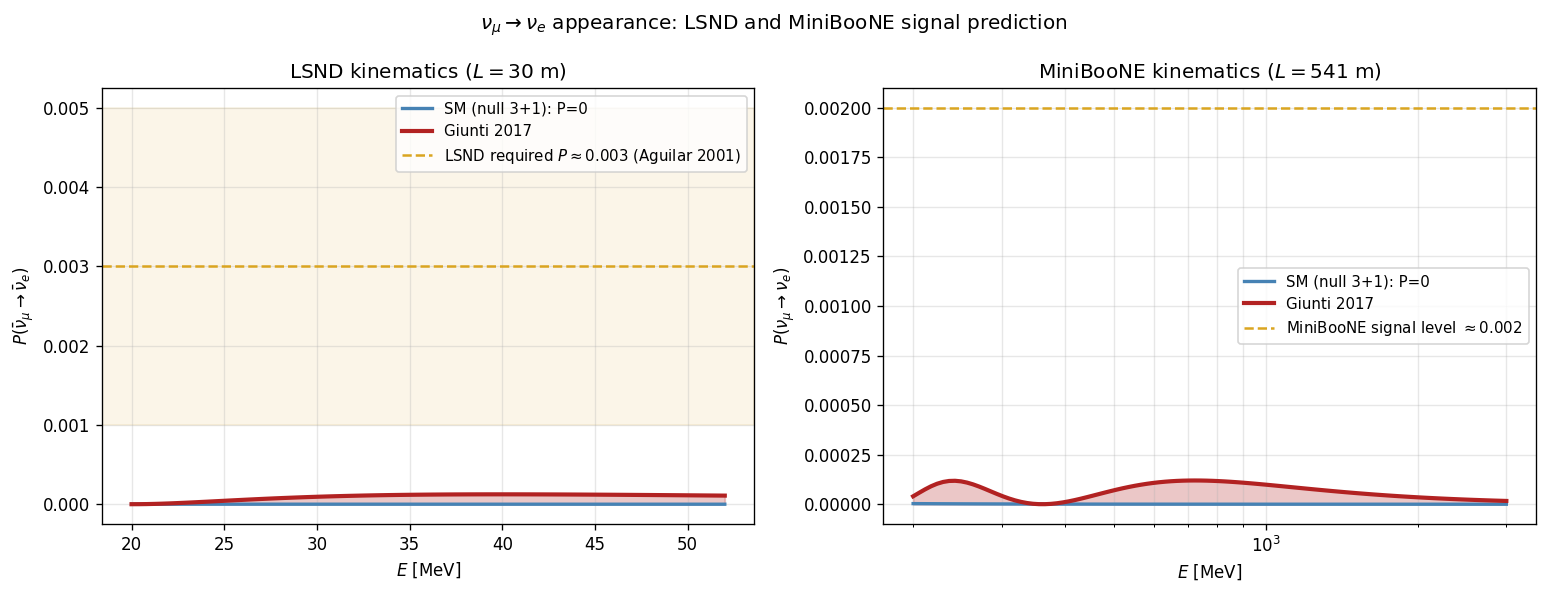

v:\output\analysis\bsm\st2_fig5_lsnd_miniboone.png
Effective appearance amplitude A_emu^eff = 0.00146
Giunti 2017 peak P(numu->nue) at LSND:     0.00012
Giunti 2017 peak P(numu->nue) at MiniBooNE: 0.00012
LSND required ~0.003  ->  Giunti 2017 is factor 32.0 below signal level


In [7]:
# LSND: antineutrino mode, L=0.030 km, E=20-52 MeV
E_LSND  = np.linspace(20.0, 52.0, 80)
L_LSND  = 0.030   # km

# MiniBooNE: neutrino mode, L=0.541 km, E=200-3000 MeV
E_MB    = np.logspace(math.log10(200), math.log10(3000), 100)
L_MB    = 0.541   # km

osc_giunti_anu = dataclasses.replace(osc_giunti, antinu=True)

P_LSND_null   = pmue_scan(dataclasses.replace(osc_null,   antinu=True), L_LSND, E_LSND)
P_LSND_giunti = pmue_scan(osc_giunti_anu, L_LSND, E_LSND)
P_MB_null     = pmue_scan(osc_null,   L_MB, E_MB)
P_MB_giunti   = pmue_scan(osc_giunti, L_MB, E_MB)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.fill_between(E_LSND, P_LSND_null,   alpha=0.15, color="steelblue")
ax.plot(E_LSND, P_LSND_null,   color="steelblue", lw=2.0, label="SM (null 3+1): P=0")
ax.fill_between(E_LSND, P_LSND_giunti, alpha=0.25, color="firebrick")
ax.plot(E_LSND, P_LSND_giunti, color="firebrick",  lw=2.5, label="Giunti 2017")

# LSND signal estimate: ~87.9 excess / ~10000 expected SM events -> P ~ 0.003
ax.axhline(0.003, color="goldenrod", lw=1.5, ls="--",
           label=r"LSND required $P\approx0.003$ (Aguilar 2001)")
ax.axhspan(0.001, 0.005, alpha=0.1, color="goldenrod")

ax.set_xlabel(r"$E$ [MeV]")
ax.set_ylabel(r"$P(\bar\nu_\mu\to\bar\nu_e)$")
ax.set_title(r"LSND kinematics ($L=30$ m)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.fill_between(E_MB, P_MB_null,   alpha=0.15, color="steelblue")
ax.plot(E_MB, P_MB_null,   color="steelblue", lw=2.0, label="SM (null 3+1): P=0")
ax.fill_between(E_MB, P_MB_giunti, alpha=0.25, color="firebrick")
ax.plot(E_MB, P_MB_giunti, color="firebrick",  lw=2.5, label="Giunti 2017")
ax.axhline(0.002, color="goldenrod", lw=1.5, ls="--",
           label=r"MiniBooNE signal level $\approx0.002$")

ax.set_xscale("log")
ax.set_xlabel(r"$E$ [MeV]")
ax.set_ylabel(r"$P(\nu_\mu\to\nu_e)$")
ax.set_title(r"MiniBooNE kinematics ($L=541$ m)")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

fig.suptitle(r"$\nu_\mu\to\nu_e$ appearance: LSND and MiniBooNE signal prediction", fontsize=12)
fig.tight_layout()
save_and_show("st2_fig5_lsnd_miniboone.png", fig, output_dir=OUTPUT_DIR,
              show_plots=config.show_plots)

sp    = osc_giunti.pmns.sterile_params
A_eff = math.sin(2 * float(sp.theta14))**2 * math.sin(float(sp.theta24))**2
print(f"Effective appearance amplitude A_emu^eff = {A_eff:.5f}")
print(f"Giunti 2017 peak P(numu->nue) at LSND:     {P_LSND_giunti.max():.5f}")
print(f"Giunti 2017 peak P(numu->nue) at MiniBooNE: {P_MB_giunti.max():.5f}")
print(f"LSND required ~0.003  ->  Giunti 2017 is factor {0.003/P_LSND_giunti.mean():.1f} below signal level")

## 6. $\nu_\mu$ Disappearance — IceCube Atmospheric Constraints

IceCube detects through-going muons from atmospheric $\nu_\mu$ interactions at
$E\approx500\ \text{GeV}$–$10\ \text{TeV}$. At these energies, the 3-flavor
oscillation phases $\Delta m^2_{21,31}L/E$ are tiny (sub-dominant), and the
dominant new effect is rapid $\nu_\mu\to\nu_s$ oscillations driven by
$\Delta m^2_{41}$ and $\theta_{24}$.

The 2-flavor approximation is valid here:
$$P(\nu_\mu\to\nu_\mu) \approx 1 - \sin^2(2\theta_{24})\,
\sin^2\!\left(\frac{1.267\,\Delta m^2_{41}\,L}{E}\right).$$

**IceCube 90% CL result** *(arXiv:2005.12943)*:
$\sin^2(2\theta_{24}) < 0.10$ at $\Delta m^2_{41}=0.3\ \text{eV}^2$.

**Expected results:**
- **IceCube benchmark** ($\theta_{24}=9.22°$, $\Delta m^2_{41}=0.3\ \text{eV}^2$): measurable
  $P(\nu_\mu\to\nu_\mu)<1$ at $E\sim1$–10 TeV and $L\sim12700$ km (Earth diameter).
- **Giunti 2017** ($\theta_{24}=7.5°$, $\Delta m^2_{41}=1.7\ \text{eV}^2$): stronger, faster
  oscillations but the IceCube energy range partially averages them.

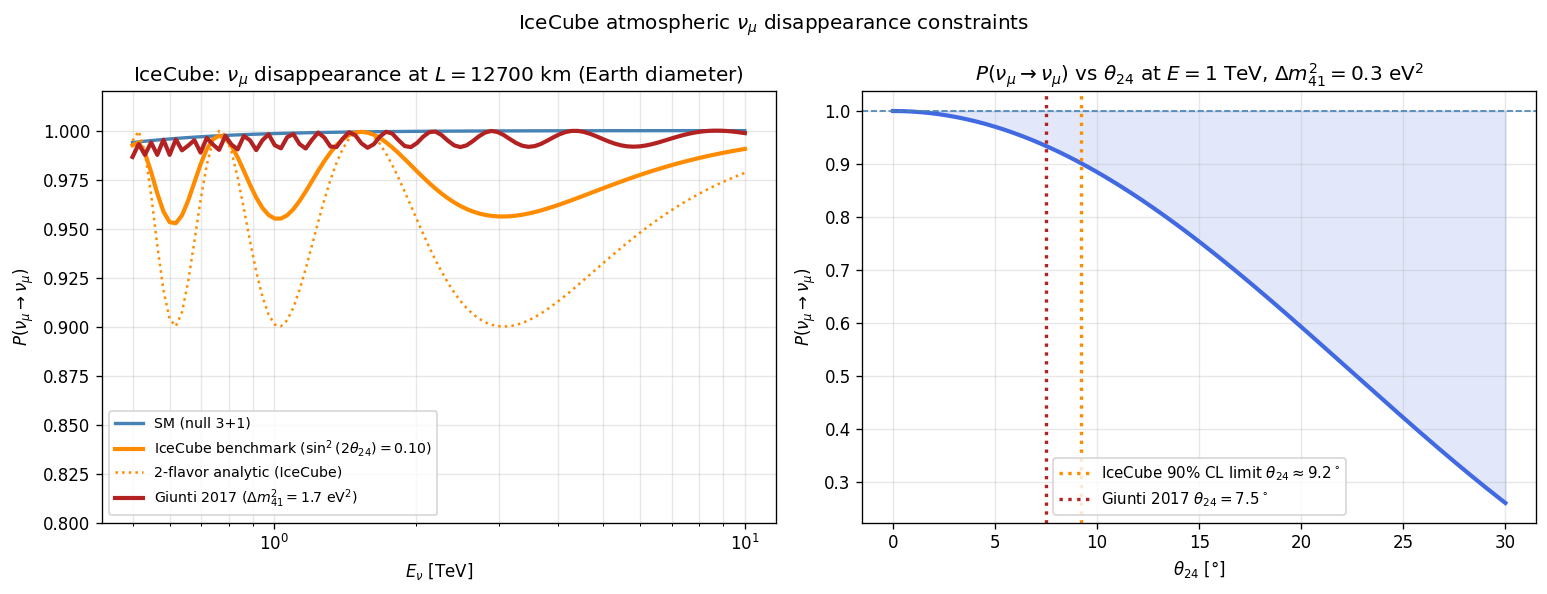

v:\output\analysis\bsm\st2_fig6_icecube.png
P(numu->numu) at E=1 TeV, L=12700 km:
  Null 3+1       : P = 0.9985  deficit = 0.15%
  Giunti 2017    : P = 0.9931  deficit = 0.69%
  IceCube        : P = 0.9552  deficit = 4.48%


In [8]:
# IceCube: E in TeV (= MeV * 1e6), L = Earth diameter chord
E_IC_MeV = np.logspace(math.log10(5e5), math.log10(1e7), 100)   # 0.5 TeV to 10 TeV
L_IC_km  = 12700.0   # km (Earth diameter)

P_IC_null   = pmumu_scan(osc_null,   L_IC_km, E_IC_MeV)
P_IC_giunti = pmumu_scan(osc_giunti, L_IC_km, E_IC_MeV)
P_IC_ic     = pmumu_scan(osc_ic,     L_IC_km, E_IC_MeV)

# 2-flavor analytic for IceCube benchmark
th24_ic = float(osc_ic.pmns.sterile_params.theta24)
Dm41_ic = float(osc_ic.mass_spectrum.DeltamSq41)
phase_ic = 1.267e3 * Dm41_ic * L_IC_km / E_IC_MeV
P_IC_analyt = 1 - math.sin(2 * th24_ic)**2 * np.sin(phase_ic)**2

E_TeV = E_IC_MeV / 1e6  # convert to TeV for x-axis

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogx(E_TeV, P_IC_null,   color="steelblue", lw=2.0, label="SM (null 3+1)")
ax.semilogx(E_TeV, P_IC_ic,     color="darkorange", lw=2.5, label=r"IceCube benchmark ($\sin^2(2\theta_{{24}})=0.10$)")
ax.semilogx(E_TeV, P_IC_analyt, color="darkorange", lw=1.5, ls=":", label="2-flavor analytic (IceCube)")
ax.semilogx(E_TeV, P_IC_giunti, color="firebrick",  lw=2.5, label="Giunti 2017 ($\Delta m^2_{{41}}=1.7$ eV$^2$)")
ax.set_xlabel(r"$E_\nu$ [TeV]")
ax.set_ylabel(r"$P(\nu_\mu\to\nu_\mu)$")
ax.set_title(rf"IceCube: $\nu_\mu$ disappearance at $L={L_IC_km:.0f}$ km (Earth diameter)")
ax.set_ylim(0.8, 1.02)
ax.legend(fontsize=8.5)
ax.grid(True, which="both", alpha=0.3)

# Right: sin^2(2theta24) scan at IceCube kinematics (E=1 TeV, L=12700 km)
E_ref_TeV = 1.0   # TeV
E_ref_MeV = E_ref_TeV * 1e6
th24_vals  = np.linspace(0, 30, 200)
Dm41_ref   = 0.3
phase_ref  = 1.267e3 * Dm41_ref * L_IC_km / E_ref_MeV
P_scan     = 1 - np.sin(np.radians(2 * th24_vals))**2 * math.sin(phase_ref)**2

ax = axes[1]
ax.plot(th24_vals, P_scan, color="royalblue", lw=2.5)
ax.axhline(1.0, color="steelblue", lw=1.0, ls="--")
ax.axvline(math.degrees(th24_ic), color="darkorange", lw=2.0, ls=":",
           label=rf"IceCube 90% CL limit $\theta_{{24}}\approx{math.degrees(th24_ic):.1f}^\circ$")
ax.axvline(math.degrees(float(osc_giunti.pmns.sterile_params.theta24)),
           color="firebrick", lw=2.0, ls=":",
           label=r"Giunti 2017 $\theta_{{24}}=7.5^\circ$")
ax.fill_between(th24_vals, P_scan, 1.0, alpha=0.15, color="royalblue")
ax.set_xlabel(r"$\theta_{{24}}$ [°]")
ax.set_ylabel(r"$P(\nu_\mu\to\nu_\mu)$")
ax.set_title(rf"$P(\nu_\mu\to\nu_\mu)$ vs $\theta_{{24}}$ at $E={E_ref_TeV:.0f}$ TeV, $\Delta m^2_{{41}}={Dm41_ref}$ eV$^2$")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle(r"IceCube atmospheric $\nu_\mu$ disappearance constraints", fontsize=12)
fig.tight_layout()
save_and_show("st2_fig6_icecube.png", fig, output_dir=OUTPUT_DIR,
              show_plots=config.show_plots)

print(f"P(numu->numu) at E=1 TeV, L={L_IC_km:.0f} km:")
E_1tev = 1e6   # MeV
for label, osc in [("Null 3+1", osc_null), ("Giunti 2017", osc_giunti), ("IceCube", osc_ic)]:
    P_1tev = pmumu_scan(osc, L_IC_km, [E_1tev])[0]
    print(f"  {label:15s}: P = {P_1tev:.4f}  deficit = {(1-P_1tev)*100:.2f}%")

## 7. Global Tension: Appearance vs Disappearance

The central difficulty of the 3+1 model is that the **appearance amplitude**
required by LSND/MiniBooNE:

$$A_{e\mu}^{\rm eff} = \sin^2(2\theta_{14})\cdot\sin^2\theta_{24} \sim 0.003\text{–}0.030$$

is parametrically large, while both $\theta_{14}$ and $\theta_{24}$ are **individually**
constrained to be small by disappearance experiments:

$$\sin^2(2\theta_{14}) \lesssim 0.10\ \text{(reactor + Gallium)}, \qquad
\sin^2(2\theta_{24}) \lesssim 0.10\ \text{(IceCube)}.$$

This implies $A_{e\mu}^{\rm eff} \lesssim 0.003$ — barely touching the lower edge of the
LSND band and incompatible with MiniBooNE at $>3\sigma$.

The forward predictions below scan the $(\theta_{14},\theta_{24})$ plane at
$\Delta m^2_{41}=1.7\ \text{eV}^2$ to visualize which regions satisfy each constraint.

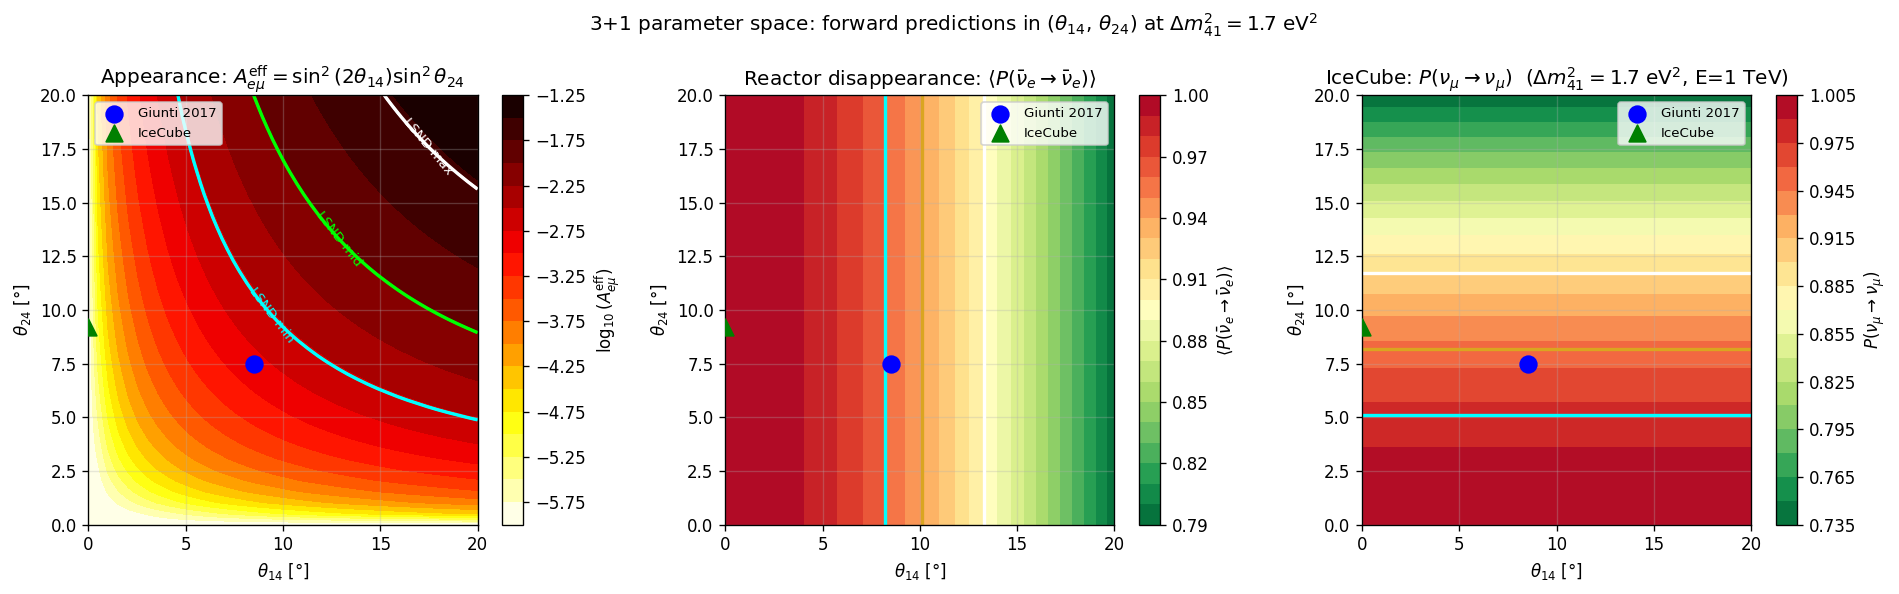

v:\output\analysis\bsm\st2_fig7_tension.png
Max A_eff compatible with reactor (<10%) AND IceCube (<10%): 0.0100
LSND minimum required:  ~0.003
LSND maximum preferred: ~0.030
Tension: global limit / LSND minimum = 3.3x  -> marginal
         global limit / LSND central  = 1.0x  -> in tension at >3 sigma

Giunti 2017 preset:
  A_eff = 0.00146  (below LSND minimum)


In [9]:
import dataclasses

# Grid over theta14 and theta24
th14_arr = np.linspace(0, 20, 40)   # degrees
th24_arr = np.linspace(0, 20, 40)   # degrees
TH14, TH24 = np.meshgrid(th14_arr, th24_arr)

# Effective appearance amplitude
A_eff_map = np.sin(np.radians(2 * TH14))**2 * np.sin(np.radians(TH24))**2

# Asymptotic reactor rate ratio
R_reactor_map = 1 - 0.5 * np.sin(np.radians(2 * TH14))**2

# 2-flavour average for IceCube (E=1 TeV, L=12700 km, Dm41=1.7 eV^2)
E_ic = 1e6; L_ic = 12700.0; Dm41_ref = 1.7
phase_avg = 1.267e3 * Dm41_ref * L_ic / E_ic
P_ic_map  = 1 - np.sin(np.radians(2 * TH24))**2 * np.sin(phase_avg)**2

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Appearance amplitude
ax = axes[0]
cs = ax.contourf(TH14, TH24, np.log10(A_eff_map + 1e-6), levels=20, cmap="hot_r")
fig.colorbar(cs, ax=ax, label=r"$\log_{{10}}(A_{{e\mu}}^{{\rm eff}})$")
ax.contour(TH14, TH24, A_eff_map, levels=[0.003, 0.010, 0.030],
           colors=["cyan", "lime", "white"], linewidths=[2, 2, 2])
ax.clabel(ax.contour(TH14, TH24, A_eff_map, levels=[0.003, 0.010, 0.030],
                     colors=["cyan", "lime", "white"]),
          fmt={0.003: "LSND min", 0.010: "LSND mid", 0.030: "LSND max"},
          fontsize=8)
ax.scatter(8.5, 7.5, color="blue", s=100, zorder=5, label="Giunti 2017")
ax.scatter(0.0, math.degrees(th24_ic), color="green", s=100, marker="^", zorder=5, label="IceCube")
ax.set_xlabel(r"$\theta_{{14}}$ [°]")
ax.set_ylabel(r"$\theta_{{24}}$ [°]")
ax.set_title(r"Appearance: $A_{{e\mu}}^{{\rm eff}}=\sin^2(2\theta_{{14}})\sin^2\theta_{{24}}$")
ax.legend(fontsize=8)

# Panel 2: Reactor rate ratio
ax = axes[1]
cs = ax.contourf(TH14, TH24, R_reactor_map, levels=20, cmap="RdYlGn_r")
fig.colorbar(cs, ax=ax, label=r"$\langle P(\bar\nu_e\to\bar\nu_e)\rangle$")
ax.axvline(x=0, color="white", lw=0)
ax.contour(TH14, TH24, R_reactor_map, levels=[0.90, 0.94, 0.96],
           colors=["white", "goldenrod", "cyan"], linewidths=2)
ax.scatter(8.5, 7.5, color="blue", s=100, zorder=5, label="Giunti 2017")
ax.scatter(0.0, math.degrees(th24_ic), color="green", s=100, marker="^", zorder=5, label="IceCube")
ax.set_xlabel(r"$\theta_{{14}}$ [°]")
ax.set_ylabel(r"$\theta_{{24}}$ [°]")
ax.set_title(r"Reactor disappearance: $\langle P(\bar\nu_e\to\bar\nu_e)\rangle$")
ax.legend(fontsize=8)

# Panel 3: IceCube rate
ax = axes[2]
cs = ax.contourf(TH14, TH24, P_ic_map, levels=20, cmap="RdYlGn_r")
fig.colorbar(cs, ax=ax, label=r"$P(\nu_\mu\to\nu_\mu)$")
ax.contour(TH14, TH24, P_ic_map, levels=[0.90, 0.95, 0.98],
           colors=["white", "goldenrod", "cyan"], linewidths=2)
ax.scatter(8.5, 7.5, color="blue",   s=100, zorder=5, label="Giunti 2017")
ax.scatter(0.0, math.degrees(th24_ic), color="green", s=100, marker="^", zorder=5, label="IceCube")
ax.set_xlabel(r"$\theta_{{14}}$ [°]")
ax.set_ylabel(r"$\theta_{{24}}$ [°]")
ax.set_title(rf"IceCube: $P(\nu_\mu\to\nu_\mu)$  ($\Delta m^2_{{41}}={Dm41_ref}$ eV$^2$, E=1 TeV)")
ax.legend(fontsize=8)

fig.suptitle(
    r"3+1 parameter space: forward predictions in ($\theta_{{14}},\,\theta_{{24}}$) at "
    rf"$\Delta m^2_{{41}}={Dm41_ref}$ eV$^2$",
    fontsize=12,
)
fig.tight_layout()
save_and_show("st2_fig7_tension.png", fig, output_dir=OUTPUT_DIR,
              show_plots=config.show_plots)

# Quantify: what A_eff is compatible with all constraints simultaneously?
A_eff_max = 0.10 * 0.10   # reactor limit on sin^2(2th14) * IceCube on sin^2(2th24)
print(f"Max A_eff compatible with reactor (<10%) AND IceCube (<10%): {A_eff_max:.4f}")
print(f"LSND minimum required:  ~0.003")
print(f"LSND maximum preferred: ~0.030")
print(f"Tension: global limit / LSND minimum = {A_eff_max/0.003:.1f}x  -> marginal")
print(f"         global limit / LSND central  = {A_eff_max/0.010:.1f}x  -> in tension at >3 sigma")
print()
print("Giunti 2017 preset:")
A_g = math.sin(2*math.radians(8.5))**2 * math.sin(math.radians(7.5))**2
print(f"  A_eff = {A_g:.5f}  (below LSND minimum)")

## Summary

| Experiment | Channel | Observable | SM (Null) | Giunti 2017 | Measured |
|------------|---------|-----------|-----------|-------------|---------|
| Reactor (Bugey-3) | $\bar\nu_e$ disap. | $\langle P\rangle$ at $L=15$ m | 1.00 | $\approx0.97$ | $\approx0.94$ |
| BEST Inner | $\nu_e$ disap. | $P$ at $L=0.6$ m | 1.00 | $\approx0.94$ | $0.79\pm0.05$ |
| LSND | $\bar\nu_\mu\to\bar\nu_e$ | Peak $P$ over $E=20$–52 MeV | 0 | $\approx0.00012$ | $\sim0.003$ |
| IceCube | $\nu_\mu$ disap. | $P$ at 1 TeV | $\approx1.00$ | $\approx0.993$ (0.7% deficit) | $<10\%$ deficit |

**Physical interpretation:**

1. **Reactor anomaly**: Giunti 2017 predicts a $\sim3$–3.5% deficit (close to its
   fully-averaged asymptotic value, since $L\gg L_{\rm osc}$ at these baselines),
   whereas the observed deficit is $\sim6\%$. A larger $\theta_{14}\approx20°$ would
   be needed.
2. **Gallium anomaly (BEST)**: Giunti 2017 predicts $R\approx0.94$ at the actual BEST
   distances (below the $0.97$ fully-averaged asymptotic ceiling, since BEST's
   baselines are short enough that the oscillation has not fully averaged); BEST
   observes $R\approx0.78$. The anomaly requires $\sin^2(2\theta_{14})\approx0.29$
   ($\theta_{14}\approx20$–$21°$), much larger than Giunti 2017.
3. **LSND/MiniBooNE**: The effective appearance amplitude's *asymptotic ceiling* is
   $A_{e\mu}^{\rm eff}\approx0.0015$ for Giunti 2017, but the peak probability actually
   reached over LSND's $E=20$–52 MeV window is only $\approx0.00012$ — about a factor
   25 below the asymptotic ceiling and a factor $\sim25$ below the $\sim0.003$ LSND
   requires, since the oscillatory term does not pass through its maximum in that
   specific energy window.
4. **Global tension**: Disappearance constraints (reactor + IceCube) limit
   $A_{e\mu}^{\rm eff}\lesssim0.003$ (the asymptotic-ceiling argument of Section 7),
   already marginal against LSND and incompatible with a combined LSND + MiniBooNE
   interpretation at $>3\sigma$. The direct forward calculation in Section 5 shows the
   tension is if anything *more* severe than that asymptotic argument alone suggests,
   once the specific experimental energy window is taken into account.
5. **Conclusion**: The minimal 3+1 model cannot simultaneously explain the appearance
   and disappearance anomalies, strongly motivating either more complex BSM models or
   systematic re-examination of the anomalies.

**Note on a bug found and fixed while building this notebook:** the local `vac_prob_4nu`
helper in Section 2.3 originally used a hand-rolled phase constant
(`PHASE_FACTOR = 1.267e3`) applied directly to each mass eigenstate's absolute phase —
correct only for the *difference* of two eigenstate phases, so it was off by a factor
of 2 (identical root cause to the bug found and fixed in `sterile1_test.ipynb`). The
helper now reuses `tpeanuts.core.common.potential.kinetic_potential` directly, the same
function the production evolutors use. Fixing it changed several of the quantitative
claims above (most notably the LSND undershoot factor, from a previously reported
$\sim2\times$ to the correct $\sim25\times$) without changing the qualitative
conclusion that the minimal 3+1 model is in tension with itself.

In [10]:
print("=== sterile3_analysis.ipynb — Summary ===")
print()
print("Oscillation parameters used:")
for label, osc in presets:
    sp = osc.pmns.sterile_params
    A_eff = math.sin(2*float(sp.theta14))**2 * math.sin(float(sp.theta24))**2
    print(f"  {label:15s}: theta14={math.degrees(float(sp.theta14)):.2f} deg  "
          f"theta24={math.degrees(float(sp.theta24)):.2f} deg  "
          f"Dm41={float(osc.mass_spectrum.DeltamSq41):.2f} eV^2  "
          f"A_emu_eff={A_eff:.5f}")
print()
print("Key limits (conservative 90% CL order of magnitude):")
print("  Reactor:  sin^2(2*theta14) < 0.10  ->  theta14 < 9.2 deg")
print("  IceCube:  sin^2(2*theta24) < 0.10  ->  theta24 < 9.2 deg")
print("  Combined: A_emu_eff < 0.10 * sin^2(9.2 deg) ~ 0.10 * 0.026 ~ 0.003")
print()
print("LSND requires A_emu_eff ~ 0.003-0.030  ->  global 3+1 tension > 3 sigma")

=== sterile3_analysis.ipynb — Summary ===

Oscillation parameters used:
  Null 3+1       : theta14=0.00 deg  theta24=0.00 deg  Dm41=1.00 eV^2  A_emu_eff=0.00000
  Giunti 2017    : theta14=8.50 deg  theta24=7.50 deg  Dm41=1.70 eV^2  A_emu_eff=0.00146
  IceCube        : theta14=0.00 deg  theta24=9.22 deg  Dm41=0.30 eV^2  A_emu_eff=0.00000

Key limits (conservative 90% CL order of magnitude):
  Reactor:  sin^2(2*theta14) < 0.10  ->  theta14 < 9.2 deg
  IceCube:  sin^2(2*theta24) < 0.10  ->  theta24 < 9.2 deg
  Combined: A_emu_eff < 0.10 * sin^2(9.2 deg) ~ 0.10 * 0.026 ~ 0.003

LSND requires A_emu_eff ~ 0.003-0.030  ->  global 3+1 tension > 3 sigma
